In [1]:
import sys
import os

sys.path.append(os.path.abspath('..')) 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib




In [3]:
# Import our modeling utilities
from src.modeling.model import (
    scale_features,
    split_by_engines,
    get_xy
)

# Auto-reload
%load_ext autoreload
%autoreload 2

In [4]:
df_train_features = pd.read_csv("../data/processed/train_features.csv")
df_test_features = pd.read_csv("../data/processed/test_features.csv")

print(df_train_features.shape, df_test_features.shape)
df_train_features.head()

(20331, 94) (12796, 93)


,engine_number,cycle,setting_1,RUL_capped,sensor_2_mean_5,sensor_2_std_5,sensor_3_mean_5,sensor_3_std_5,sensor_4_mean_5,sensor_4_std_5,...,sensor_8_lag_3,sensor_9_lag_3,sensor_11_lag_3,sensor_12_lag_3,sensor_13_lag_3,sensor_14_lag_3,sensor_15_lag_3,sensor_17_lag_3,sensor_20_lag_3,sensor_21_lag_3
0,1,4,0.0007,130,642.1675,0.250117,1588.075,3.855909,1402.4525,1.559645,...,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1,5,-0.0019,130,642.2080,0.234776,1587.030,4.075678,1403.2060,2.159440,...,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1,6,-0.0043,130,642.2640,0.128374,1585.984,3.885831,1402.7600,2.926337,...,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1,7,0.0010,130,642.3300,0.139463,1586.084,4.075375,1401.6860,3.648360,...,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1,8,-0.0034,130,642.3720,0.174270,1585.078,4.107952,1401.0400,3.367046,...,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044


In [5]:
#fit scaler on training data only
df_train_scaled, scaler = scale_features(df_train_features, is_fit=True)

#verify scaling worked
feature_cols = [col for col in df_train_scaled.columns 
                if col not in ['engine_number', 'cycle', 'RUL_capped']]

df_train_scaled[feature_cols[:5]].describe().T[['mean', 'std']]

,mean,std
setting_1,-2.236719e-17,1.000025
sensor_2_mean_5,6.177958e-14,1.000025
sensor_2_std_5,-3.914258e-17,1.000025
sensor_3_mean_5,-2.553215e-14,1.000025
sensor_3_std_5,-1.653075e-16,1.000025


In [6]:
# transform test using same scaler  don't fit again
df_test_scaled, _ = scale_features(df_test_features, scaler=scaler, is_fit=False)
print(df_test_scaled.shape)

(12796, 93)


In [7]:
# save scaler for later
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")
print("saved scaler")

saved scaler


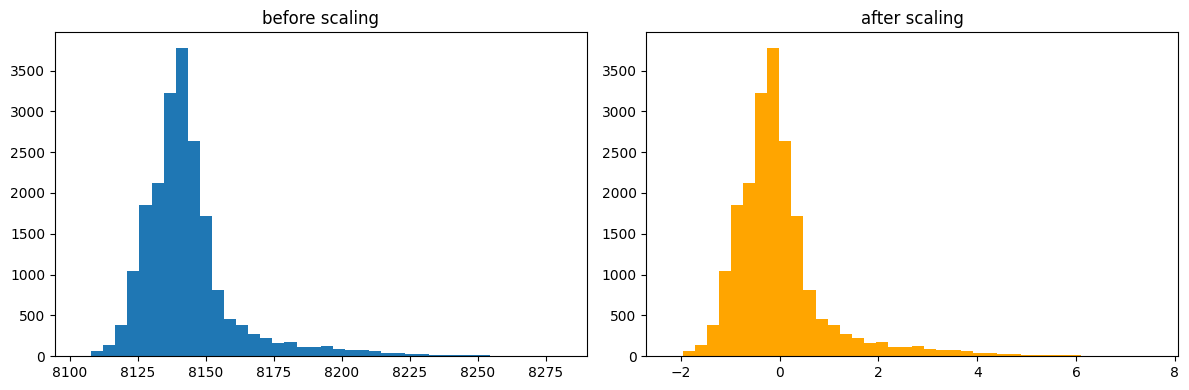

In [8]:
# does scaling look right?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train_features['sensor_14_mean_5'], bins=40)
axes[0].set_title('before scaling')

axes[1].hist(df_train_scaled['sensor_14_mean_5'], bins=40, color='orange')
axes[1].set_title('after scaling')

plt.tight_layout()
plt.show()
# centered around 0 now, good

In [ ]:
#split scaled training data into train/validation by engine ID
df_train_split, df_val_split = split_by_engines(
    df_train_scaled,
    train_engines=70,   #first 70 engines for training
    val_engines=15      #next 15 engines for validation
)



train: 13920 rows, val: 3165 rows


In [10]:
# make sure no engine overlap between train and val
train_ids = set(df_train_split['engine_number'].unique())
val_ids = set(df_val_split['engine_number'].unique())

print(len(train_ids), len(val_ids))
print(len(train_ids & val_ids))  # should be 0

70 15
0


In [11]:
X_train, y_train = get_xy(df_train_split)
X_val, y_val = get_xy(df_val_split)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(13920, 91) (13920,)
(3165, 91) (3165,)


In [12]:
X_test, _ = get_xy(df_test_scaled)
print(X_test.shape)

(12796, 91)


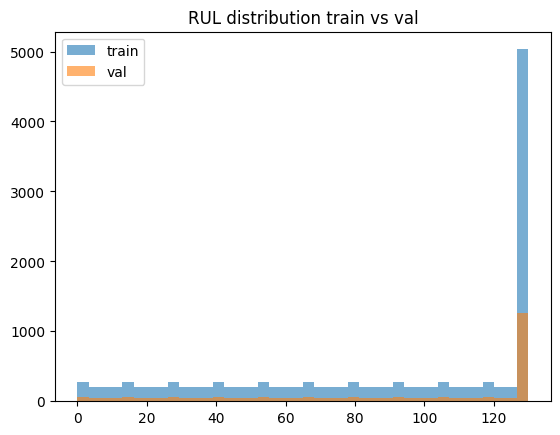

In [13]:
#do train and val have similar RUL distributions?
plt.hist(y_train, bins=40, alpha=0.6, label='train')
plt.hist(y_val, bins=40, alpha=0.6, label='val')
plt.legend()
plt.title('RUL distribution train vs val')
plt.show()
# looks similar, good

## notes

- scaled with StandardScaler, fit on train only
- split 70 train / 15 val by engine number
- no overlap between train and val engines
- scaler saved to models/scaler.pkl
- ready for modeling